# HVSR con Geopsy: preparar, procesar y comparar

Este cuaderno integra **Geopsy** en el flujo HVSR: Python/ObsPy prepara y valida las tres componentes SAC, exporta un MiniSEED sincronizado que Geopsy admite, documenta los ajustes en su herramienta H/V y carga de vuelta el resultado `.hv` para graficarlo y contrastarlo.

> **Alcance real:** Geopsy es una aplicacion geofisica, no un modulo Python importable. Su herramienta H/V se configura y ejecuta en la interfaz grafica. La interfaz de linea documentada `geopsy -waveform` automatiza operaciones sobre formas de onda, pero no encontre una interfaz batch documentada para ejecutar la caja de herramientas H/V completa. Este cuaderno automatiza preparacion, validacion, exportacion y analisis del `.hv`; el calculo central se ejecuta en Geopsy.

Flujo: SAC sincronizados -> ObsPy valida canales/metadatos -> MiniSEED de tres trazas -> Geopsy H/V (seleccion y procesamiento) -> exportar `.hv` + `.log` -> importar curva a Python.

**Diferencias metodologicas que se deben conservar en la interpretacion:** Geopsy ofrece anti-trigger y ventanas comunes a las tres componentes. Su documentacion indica que combina N/E antes de suavizar H y Z, mientras el MATLAB suaviza cada componente antes de combinar las horizontales. Aunque ambos usen Konno-Ohmachi y promedio horizontal cuadratico, no se espera identidad numerica.

In [8]:
from pathlib import Path
import os
import shutil
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import obspy
from obspy import Stream, read

PARAMS = {
    # Geopsy Time tab: exact fixed windows plus anti-trigger on raw signal.
    "window_s": 32.0,
    "overlap_percent": 0.0,
    "anti_trigger": True,
    "raw_sta_s": 2.0,
    "raw_lta_s": 25.0,
    "raw_ratio_min": 0.2,
    "raw_ratio_max": 2.0,
    "bad_sample_threshold_percent": 99.0,
    # Geopsy Processing and Output tabs.
    "smoothing": "konno & ohmachi",
    "smoothing_constant": 40.0,
    "cosine_taper": True,
    "taper_width_percent": 2.0,
    "horizontal_method": "squared average",
    "fmin_hz": 0.5,
    "fmax_hz": 30.0,
    "frequency_sampling": "log",
    "number_frequency_samples": 1000,
}

_search_roots = (Path.cwd().resolve(),)
PROJECT_ROOT = next(
    (parent for start in _search_roots for parent in (start, *start.parents)
     if (parent / "HVMATLAB").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("No encuentro la carpeta HVMATLAB desde el directorio de trabajo actual.")
SAC_DIR = PROJECT_ROOT / "HVMATLAB"
SAC_FILES = {
    "E": SAC_DIR / "00P2-2_WA.WAU40..HHE.D.2020.281.sac",
    "N": SAC_DIR / "00P2-2_WA.WAU40..HHN.D.2020.281.sac",
    "Z": SAC_DIR / "00P2-2_WA.WAU40..HHZ.D.2020.281.sac",
}
GEOPSY_EXE = os.environ.get("GEOPSY_BIN") or shutil.which("geopsy")
WORK_DIR = PROJECT_ROOT / "main" / "02_analysis_hv" / "outputs_geopsy"
WORK_DIR.mkdir(parents=True, exist_ok=True)

print(f"Geopsy handoff | ObsPy {obspy.__version__} | NumPy {np.__version__}")
print(f"Raiz del proyecto: {PROJECT_ROOT}")
print(f"Ejecutable Geopsy: {GEOPSY_EXE or 'no encontrado en PATH'}")
print("Ajustes objetivo:")
for key, value in PARAMS.items():
    print(f"  {key}: {value}")

Geopsy handoff | ObsPy 1.5.1 | NumPy 2.4.6
Raiz del proyecto: /home/orincon/ciudad-perdida-hvsr
Ejecutable Geopsy: no encontrado en PATH
Ajustes objetivo:
  window_s: 32.0
  overlap_percent: 0.0
  anti_trigger: True
  raw_sta_s: 2.0
  raw_lta_s: 25.0
  raw_ratio_min: 0.2
  raw_ratio_max: 2.0
  bad_sample_threshold_percent: 99.0
  smoothing: konno & ohmachi
  smoothing_constant: 40.0
  cosine_taper: True
  taper_width_percent: 2.0
  horizontal_method: squared average
  fmin_hz: 0.5
  fmax_hz: 30.0
  frequency_sampling: log
  number_frequency_samples: 1000


## 1. Que automatizamos y que se hace en Geopsy

Geopsy documenta SAC como formato de entrada y MiniSEED como lectura/escritura. Este cuaderno crea un archivo MiniSEED unico con las tres trazas, todas con la misma estacion y canales `HHZ`, `HHN`, `HHE`. No cambia los SAC fuente. El codigo de estacion `HV01` del export es una etiqueta local para agrupar los canales; no reemplaza los metadatos cientificos originales.

La ruta GUI oficial es: abrir el MiniSEED -> comprobar que Geopsy reconoce Z/N/E como una estacion -> seleccionar **Tools > H/V spectral ratio** -> configurar Time, Processing y Output -> Start -> exportar `*.hv` y `*.log`. En el H/V documentado, Geopsy necesita tres senales, suficientes muestras comunes y un nombre de estacion comun.

**Importante:** el cuaderno puede preparar los datos, detectar si el ejecutable esta instalado e importar el resultado; la seleccion de ventanas y el calculo H/V se realizan dentro del programa Geopsy. Ejecutar `geopsy -waveform` no ejecuta por si solo el plugin H/V.

In [9]:
missing_sac = [str(path) for path in SAC_FILES.values() if not path.is_file()]
if missing_sac:
    raise FileNotFoundError("No existen estos SAC: " + ", ".join(missing_sac))

source_traces = {component: read(str(path), format="SAC")[0] for component, path in SAC_FILES.items()}
reference = source_traces["Z"]
fs = float(reference.stats.sampling_rate)
dt = float(reference.stats.delta)
for component, trace in source_traces.items():
    assert trace.stats.npts == reference.stats.npts, f"Longitud no coincide: {component}"
    assert np.isclose(trace.stats.delta, dt), f"dt no coincide: {component}"
    assert trace.stats.starttime == reference.stats.starttime, f"Inicio no coincide: {component}"
    assert np.all(np.isfinite(trace.data)), f"NaN/inf en {component}"

# Geopsy necesita identificar un trio co-registrado: se normalizan solo las cabeceras
# del archivo derivado; las muestras originales y los SAC fuente no se modifican.
channel_code = {"Z": "HHZ", "N": "HHN", "E": "HHE"}
normalized_stream = Stream()
for component in ("Z", "N", "E"):
    normalized = source_traces[component].copy()
    normalized.stats.network = "XX"
    normalized.stats.station = "HV01"
    normalized.stats.location = ""
    normalized.stats.channel = channel_code[component]
    normalized_stream.append(normalized)

MSEED_PATH = WORK_DIR / "HV01_triplet.mseed"
normalized_stream.write(str(MSEED_PATH), format="MSEED", encoding="FLOAT32")

# Reabrir el derivado comprueba que el intercambio no perdio el orden ni el muestreo.
roundtrip = read(str(MSEED_PATH), format="MSEED")
roundtrip_by_component = {trace.stats.channel[-1]: trace for trace in roundtrip}
assert set(roundtrip_by_component) == {"Z", "N", "E"}
assert len(roundtrip) == 3
for component, trace in roundtrip_by_component.items():
    assert trace.stats.npts == reference.stats.npts
    assert np.isclose(trace.stats.delta, dt)
    assert trace.stats.starttime == reference.stats.starttime

Data = np.column_stack((roundtrip_by_component["Z"].data,
                        roundtrip_by_component["N"].data,
                        roundtrip_by_component["E"].data)).astype(float)
time_s = np.arange(Data.shape[0]) * dt
nyquist = fs / 2.0
print(f"SAC fuente: {Data.shape[0]:,} muestras/componente; dt={dt:g} s; Fs={fs:g} Hz")
print(f"Nyquist={nyquist:g} Hz; duracion={(len(Data)-1)*dt:.3f} s")
print("Orden de Data: Z, N, E")
print("MiniSEED para Geopsy:", MSEED_PATH, f"({MSEED_PATH.stat().st_size / 1e6:.1f} MB)")
print("Canales exportados:", [trace.id for trace in roundtrip])
assert PARAMS["fmax_hz"] <= nyquist

SAC fuente: 2,816,100 muestras/componente; dt=0.01 s; Fs=100 Hz
Nyquist=50 Hz; duracion=28160.990 s
Orden de Data: Z, N, E
MiniSEED para Geopsy: /home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_geopsy/HV01_triplet.mseed (34.3 MB)
Canales exportados: ['XX.HV01..HHZ', 'XX.HV01..HHN', 'XX.HV01..HHE']


## 2. Ajustes del toolbox H/V de Geopsy

Abre `outputs_geopsy/HV01_triplet.mseed` en Geopsy, selecciona las tres componentes del mismo registro y elige **Tools > H/V spectral ratio**. Comprueba en el visor que hay tres trazas alineadas y que Geopsy las identifica como N, E y Z.

| Toolbox de Geopsy | Valor objetivo | Relacion con MATLAB / cautela |
|---|---:|---|
| Time: window length type | `exactly` | Ventanas fijas; minimo=maximo=32 s. |
| Time: window min/max | 32 / 32 s | MATLAB actual fuerza `tmin=32` porque `tvar=0`. |
| Time: window overlap | desactivado; 0 % | Igual al input MATLAB. |
| Time: Select | `Auto` | Inicia la seleccion automatica; inspecciona las ventanas coloreadas antes de Start. |
| Time: anti-trigger on raw signal | activado | Usar componentes comunes N/E/Z. Configurar STA=2 s, LTA=25 s, min SLTA=0.2 y max SLTA=2. |
| Time: bad sample threshold | activado; 99 % | Aproxima la exclusion MATLAB de muestras mayores que 99 % del maximo. Verifica como interpreta el maximo la version de Geopsy. |
| Processing: smoothing | Konno & Ohmachi; constant=40 | Mismo nombre y constante que MATLAB, pero Geopsy combina horizontales antes de suavizar. |
| Processing: cosine taper | activado; width=2 % | Es una rampa cosenoidal normal; no copia el taper defectuoso de 2 % del MATLAB. |
| Horizontal components | Squared average | H = sqrt((N^2 + E^2) / 2), coincide con la definicion de horizontal. |
| Output: frequency from/to | 0.5 / 30 Hz | Igual banda solicitada; confirmar que 30 Hz < Nyquist (=50 Hz). |
| Output: sampling | Log; por ejemplo 1000 puntos | Geopsy usa frecuencias logaritmicas; MATLAB usa bins FFT lineales. No comparar indices directamente. |
| Output section | activada | Exporta un `.hv` de curva y un `.log` con parametros/ventanas. |

Al pulsar Start, Geopsy selecciona ventanas comunes a los tres canales. Revisa visualmente las ventanas coloreadas y guarda los resultados en `outputs_geopsy/`. La GUI es necesaria para esta etapa en la instalacion actual: el ejecutable `geopsy` no esta disponible en `PATH`.

## 3. Leer el `.hv` que exporta Geopsy

El `.hv` contiene comentarios de cabecera y filas numericas: frecuencia, curva H/V media, curva baja y curva alta. Geopsy guarda ademas el pico fundamental y el numero de ventanas en comentarios; el `.log` es la referencia para reconstruir parametros y ventanas. El lector ignora comentarios y filas no numericas, sin asumir que el fichero sea un CSV convencional.

Cuando aun no exista `.hv`, ejecuta Geopsy y guarda el resultado dentro de `outputs_geopsy/`; vuelve a ejecutar la siguiente celda. Si hay varios ficheros, puedes indicar explicitamente `GEOPSY_HV_PATH`.

In [10]:
def _numbers_after(text, marker):
    """Extrae numeros que aparecen despues de una etiqueta en la cabecera .hv."""
    tail = text.lower().split(marker.lower(), 1)[1]
    values = []
    for token in tail.replace("=", " ").replace(",", " ").replace("\t", " ").split():
        try:
            values.append(float(token))
        except ValueError:
            continue
    return values


def parse_geopsy_hv(path):
    """Lee curvas .hv (frecuencia, media, limite bajo, limite alto) y cabecera."""
    path = Path(path)
    metadata = {}
    numeric_rows = []
    with path.open("r", encoding="utf-8", errors="replace") as handle:
        for line in handle:
            lower_line = line.lower()
            if "f0 from average" in lower_line:
                values = _numbers_after(line, "f0 from average")
                if values:
                    metadata["f0_average_hz"] = values[0]
            if "number of windows" in lower_line:
                values = _numbers_after(line, "number of windows")
                if values:
                    metadata["number_of_windows"] = int(values[0])
            if "f0 from windows" in lower_line:
                values = _numbers_after(line, "f0 from windows")
                if values:
                    metadata["f0_window_summary"] = values
            if line.lstrip().startswith("#"):
                continue
            fields = line.replace(",", " ").split()
            try:
                row = [float(field) for field in fields]
            except ValueError:
                continue
            if len(row) >= 4 and row[0] > 0 and np.all(np.isfinite(row[:4])):
                numeric_rows.append(row[:4])
    if not numeric_rows:
        raise ValueError(f"No encontre filas numericas de 4 columnas en {path}")
    curve = np.asarray(numeric_rows, dtype=float)
    if np.any(np.diff(curve[:, 0]) <= 0):
        raise ValueError("Las frecuencias del .hv deben ser estrictamente crecientes.")
    return curve, metadata


def launch_geopsy_with_input():
    """Abre el MiniSEED en Geopsy si esta instalado; no ejecuta H/V automaticamente."""
    if not GEOPSY_EXE:
        raise FileNotFoundError("Geopsy no esta en PATH. Abre el programa y carga manualmente: " + str(MSEED_PATH))
    return subprocess.Popen([GEOPSY_EXE, str(MSEED_PATH)])

GEOPSY_HV_PATH = None  # Opcional: Path('/ruta/al/resultado.hv')
hv_candidates = sorted(WORK_DIR.glob("*.hv"))
if GEOPSY_HV_PATH is None and hv_candidates:
    GEOPSY_HV_PATH = hv_candidates[-1]

if GEOPSY_HV_PATH is None:
    geopsy_curve = None
    geopsy_metadata = {}
    print("Aun no hay un .hv. Ejecuta H/V en Geopsy, activa Output, guarda el resultado en:", WORK_DIR)
else:
    GEOPSY_HV_PATH = Path(GEOPSY_HV_PATH)
    geopsy_curve, geopsy_metadata = parse_geopsy_hv(GEOPSY_HV_PATH)
    print("Curva importada:", GEOPSY_HV_PATH)
    print("Metadatos .hv:", geopsy_metadata)
    print(f"Filas={len(geopsy_curve)}; f0 max de curva={geopsy_curve[np.argmax(geopsy_curve[:, 1]), 0]:.5g} Hz")

    geopsy_csv_path = WORK_DIR / (GEOPSY_HV_PATH.stem + "_imported.csv")
    np.savetxt(geopsy_csv_path, geopsy_curve, delimiter=",",
               header="frequency_hz,HV_mean,HV_lower,HV_upper", comments="")
    print("CSV numerico guardado:", geopsy_csv_path)

    fig, axis = plt.subplots(figsize=(10, 5), constrained_layout=True)
    axis.plot(geopsy_curve[:, 0], geopsy_curve[:, 1], color="black", lw=1.7, label="Geopsy: H/V medio")
    axis.fill_between(geopsy_curve[:, 0], geopsy_curve[:, 2], geopsy_curve[:, 3],
                      color="steelblue", alpha=0.22, label="Limites bajo/alto exportados")
    if "f0_average_hz" in geopsy_metadata:
        axis.axvline(geopsy_metadata["f0_average_hz"], color="crimson", ls="--",
                     label=f"f0 Geopsy={geopsy_metadata['f0_average_hz']:.3g} Hz")
    axis.set_xscale("log")
    axis.set_xlim(PARAMS["fmin_hz"], min(PARAMS["fmax_hz"], nyquist))
    axis.set_xlabel("Frecuencia (Hz)")
    axis.set_ylabel("H/V")
    axis.set_title("Curva H/V exportada por Geopsy")
    axis.grid(alpha=0.25)
    axis.legend()
    plt.show()

    python_curve_path = PROJECT_ROOT / "main" / "02_analysis_hv" / "outputs_hvsr" / "hv_curve.csv"
    if python_curve_path.is_file():
        python_curve = np.genfromtxt(python_curve_path, delimiter=",", names=True)
        common = (geopsy_curve[:, 0] >= python_curve["frequency_hz"].min()) & (geopsy_curve[:, 0] <= python_curve["frequency_hz"].max())
        python_interp = np.interp(geopsy_curve[common, 0], python_curve["frequency_hz"], python_curve["HV_geometric_mean"])
        log_difference = np.log10(np.maximum(geopsy_curve[common, 1], np.finfo(float).tiny) /
                                  np.maximum(python_interp, np.finfo(float).tiny))
        print("Comparacion exploratoria con outputs_hvsr/hv_curve.csv:")
        print(f"  mediana log10(Geopsy/Python)={np.median(log_difference):.4g}")
        print(f"  mediana |log10(Geopsy/Python)|={np.median(np.abs(log_difference)):.4g}")
        print("  Diferencias esperadas: ventanas, taper, orden de suavizado y malla de frecuencias no son identicos.")

Aun no hay un .hv. Ejecuta H/V en Geopsy, activa Output, guarda el resultado en: /home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_geopsy


In [11]:
from tempfile import TemporaryDirectory

with TemporaryDirectory() as temporary_directory:
    sample_hv = Path(temporary_directory) / "format_check.hv"
    sample_hv.write_text(
        "# Number of windows = 2\n# f0 from average 1.25\n"
        "# Frequency Average Min Max\n0.5 1.0 0.8 1.2\n1.0 2.0 1.5 2.5\n",
        encoding="utf-8",
    )
    sample_curve, sample_metadata = parse_geopsy_hv(sample_hv)
    assert sample_curve.shape == (2, 4)
    assert sample_metadata["number_of_windows"] == 2
    assert np.isclose(sample_metadata["f0_average_hz"], 1.25)
print("Smoke test del parser .hv superado.")

GEOPSY_SETTINGS_PATH = WORK_DIR / "geopsy_gui_settings.json"
import json
with GEOPSY_SETTINGS_PATH.open("w", encoding="utf-8") as handle:
    json.dump({
        "input_mseed": str(MSEED_PATH),
        "channels": {"vertical": "HHZ", "north": "HHN", "east": "HHE"},
        "sampling_rate_hz": fs,
        "dt_seconds": dt,
        "params_to_enter_in_geopsy_gui": PARAMS,
        "important_differences_from_matlab": [
            "Geopsy combina N/E antes del suavizado; MATLAB suaviza cada horizontal antes de combinarlas.",
            "Geopsy aplica taper cosenoidal estandar; MATLAB usa una implementacion de borde distinta.",
            "La seleccion de ventanas anti-trigger no garantiza los mismos indices que el trigger MATLAB.",
            "Geopsy muestrea la curva sobre su malla elegida; comparar tras interpolar en frecuencia.",
        ],
    }, handle, indent=2, ensure_ascii=False)
print("Configuracion de trazabilidad guardada:", GEOPSY_SETTINGS_PATH)

Smoke test del parser .hv superado.
Configuracion de trazabilidad guardada: /home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_geopsy/geopsy_gui_settings.json


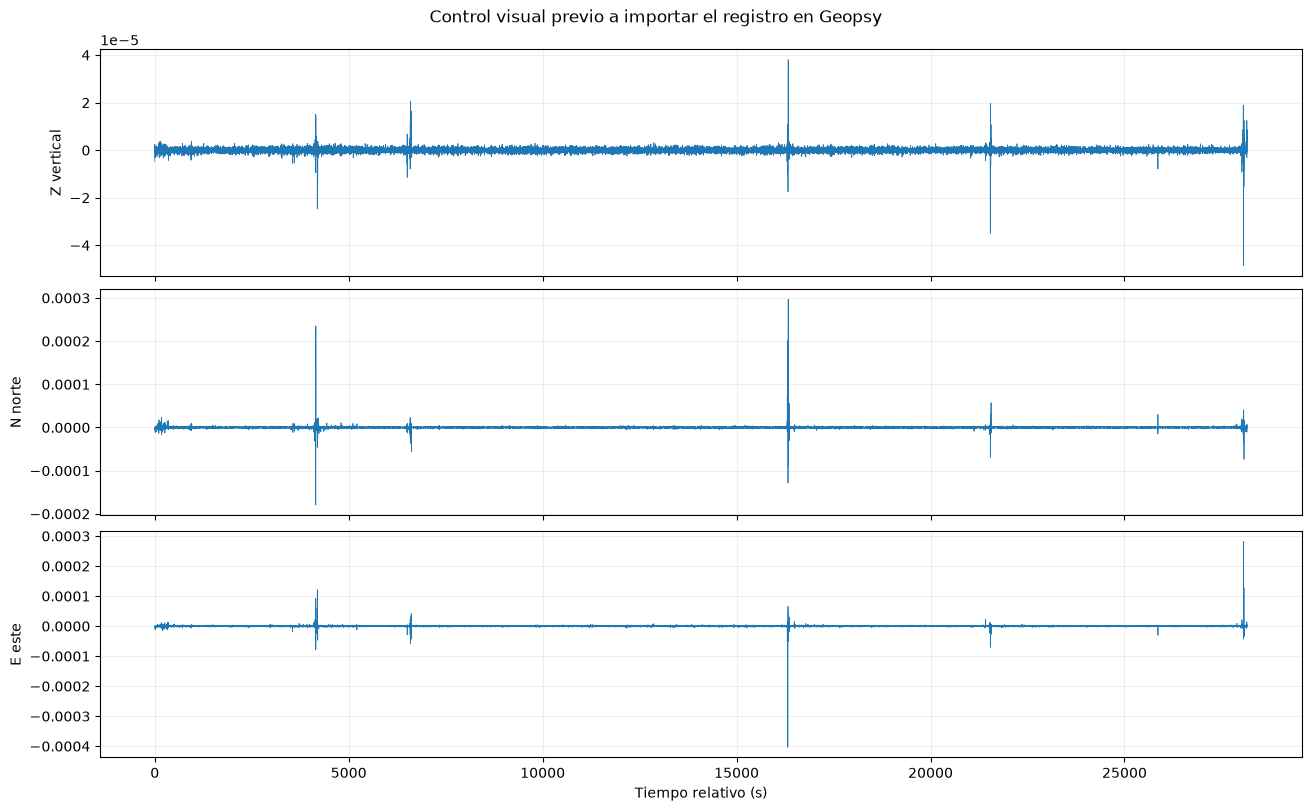

Registro: 7.82 horas; stride de visualizacion=140 muestras
Esta figura es solo control de entrada; la ventana final la selecciona el toolbox H/V de Geopsy.


In [7]:
plot_stride = max(1, len(time_s) // 20000)
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True, constrained_layout=True)
for component_index, (component, label) in enumerate(((0, "Z vertical"), (1, "N norte"), (2, "E este"))):
    axes[component_index].plot(time_s[::plot_stride], Data[::plot_stride, component], lw=0.55)
    axes[component_index].set_ylabel(label)
    axes[component_index].grid(alpha=0.2)
axes[-1].set_xlabel("Tiempo relativo (s)")
fig.suptitle("Control visual previo a importar el registro en Geopsy")
plt.show()
print(f"Registro: {time_s[-1] / 3600:.2f} horas; stride de visualizacion={plot_stride} muestras")
print("Esta figura es solo control de entrada; la ventana final la selecciona el toolbox H/V de Geopsy.")

## Referencias oficiales

- [Tutorial Geopsy H/V spectral ratio](https://www.geopsy.org/wiki/index.php/H/V_spectral_ratio)
- [Parametros de procesamiento H/V (suavizado, taper y combinacion horizontal)](https://www.geopsy.org/wiki/index.php/Geopsy:_H/V_and_Spectrum_Toolboxes:_Processing_Tab)
- [Parametros de tiempo y seleccion de ventanas](https://www.geopsy.org/wiki/index.php/Geopsy:_H/V_and_Spectrum_Toolboxes:_Time_Tab)
- [Salida H/V: frecuencia, `.hv` y `.log`](https://www.geopsy.org/wiki/index.php/Geopsy:_H/V_and_Spectrum_Toolboxes:_Output_Tab)
- [Formato numerico del fichero `.hv`](https://www.geopsy.org/wiki/index.php/Geopsy:_H/V_output_file)
- [Formatos admitidos: SAC y MiniSEED](https://www.geopsy.org/wiki/index.php/Geopsy:_Supported_file_formats)
- Wathelet et al. (2020), *Geopsy: A User-Friendly Open-Source Tool Set for Ambient Vibration Processing*, [doi:10.1785/0220190360](https://doi.org/10.1785/0220190360).